# Modified Nodal Analysis

In [36]:
import math
from vpython import graph, gcurve, color, canvas

canvas()

# RC LOW-PASS FILTER 
#implemented RC low pass filter during senior design using these values:
#1 kohm + 0.1 microF 
#dt found via time constant tau (T) T = RC
#https://www.electronics-tutorials.ws/filter/filter_2.html
R = 1000
C = 0.0000001
fc = (1 / (2 * math.pi * R * C)) #cut off freq around 1591
V = 5

# log spaced frequencies for bode plot
freqs = [10 ** (f / 10) for f in range(10, 61)]  # 10 Hz to 100kHz log spaced

# g = graph(title='RC Filter Bode Plot', xtitle='Frequency (Hz)', ytitle='Magnitude (dB) / Phase (deg)', logx=True)
# mag_curve = gcurve(graph=g, color=color.blue, label='Magnitude (dB)')
# phase_curve = gcurve(graph=g, color=color.red, label='Phase (deg)')
# cutoff_mark = gcurve(graph=g, color=color.green, label=f'Cutoff fc = {fc:.0f} Hz')

for freq in freqs:
    dt = min(R * C, 1 / (20 * freq))  # dt = 20 samples per cycle
    Req = dt / C
    Veq = 0
    T = 1 / freq
    t = 0

    # 20 cycles to reach steady state
    while t < 20 * T:
        Vin = V * math.sin(2 * math.pi * freq * t)
        Ieq = -(C / dt) * Veq  
        Veq = (Vin / R - Ieq) / (1 / R + 1 / Req)
        t += dt

    # measure peak and phase over 2 steady state cycles
    peaks = []
    while t < 22 * T:
        Vin = V * math.sin(2 * math.pi * freq * t)
        Ieq = -(C / dt) * Veq  
        Veq = (Vin / R - Ieq) / (1 / R + 1 / Req)
        peaks.append(Veq)
        t += dt

#     # magnitude
#     gain = max(abs(p) for p in peaks) / V
#     dB = 20 * math.log10(gain)
#     mag_curve.plot(freq, dB)

#     # phase = -arctan(f/fc) 
#     phase = -math.degrees(math.atan(freq / fc))
#     phase_curve.plot(freq, phase)

# # vertical line at fc by plotting two points: top and bottom of the graph
# cutoff_mark.plot(fc, 10)
# cutoff_mark.plot(fc, -100)


# HALF WAVE RECTIFIER 
#Similar site for half-wave:
#used silicon diode parameters from reference
#https://www.electronics-tutorials.ws/diode/diode_1.html
#https://www.electronics-tutorials.ws/diode/diode_5.html
VD = 0.7
Is = 1e-14
n = 1 #idealy
VT = 0.02585 #Theraml Voltage at room temp
R2 = 100000 #resistor from the given circuit 
#V = 5 used from RC filter 
#C = 0.0000001 same as RC

f = 10000 #freq of sine
T2 = 1/f
t_end = 0.003 #from the given circuit
dt2 = 1 / (20 * f) #20 samples per cycle

# #initial diode companion model
# ID = Is * (math.exp(VD / (n * VT)) - 1)
# GDeg = (Is/(n*VT))*(math.exp(VD/(n*VT)))
# IDeg = ID - GDeg*VD

g2 = graph(title=f'Half Wave Rectifier | f={f} Hz  R={R2} Ω  C={C} F', xtitle='Time (s)', ytitle='Voltage (V)')
vin_curve = gcurve(graph=g2, color=color.red, label='Vin')
vb_curve = gcurve(graph=g2, color=color.blue, label='Vb')

t2 = 0
Vb = 0

while t2 < t_end:
    Va = V * math.sin(2 * math.pi * f * t2)
    #convergence loop with VD as first guess
    VQ = VD 
    converged = False
    max_iter = 100
    cur_iter = 0

    while not converged:
        # update diode companion model at operating point VQ
        ID = Is * (math.exp(VQ / (n * VT)) - 1)
        GDeq = (Is / (n * VT)) * math.exp(VQ / (n * VT))
        IDeq = ID - GDeq * VQ

        # capacitor companion 
        Geq_cap = C / dt2
        Iceq = -Geq_cap * Vb

        Vb_next = (IDeq + GDeq * Va - Iceq) / (GDeq + Geq_cap + 1 / R2)
        VD_new = Va - Vb_next

        # check convergence: voltage difference < 0.001V
        if abs(VD_new - VQ) < 0.001:
            converged = True
            VD = VD_new
            Vb = Vb_next
        else:
            VQ = VD_new
            cur_iter += 1

            # if not converging after max iterations, decrease dt and reset
            if cur_iter > max_iter:
                dt2 = dt2 / 2
                VQ = VD  # reset guess
                cur_iter = 0

                if dt2 < 1e-10:
                    print(f"Error: failed to converge at t={t2:.6f}")
                    break
                    
    vin_curve.plot(t2, Va)
    vb_curve.plot(t2, Vb)
    t2 += dt2
    dt2 = 1 / (1 * f)


<IPython.core.display.Javascript object>

a.
Lt Spice Simulation RC filter: 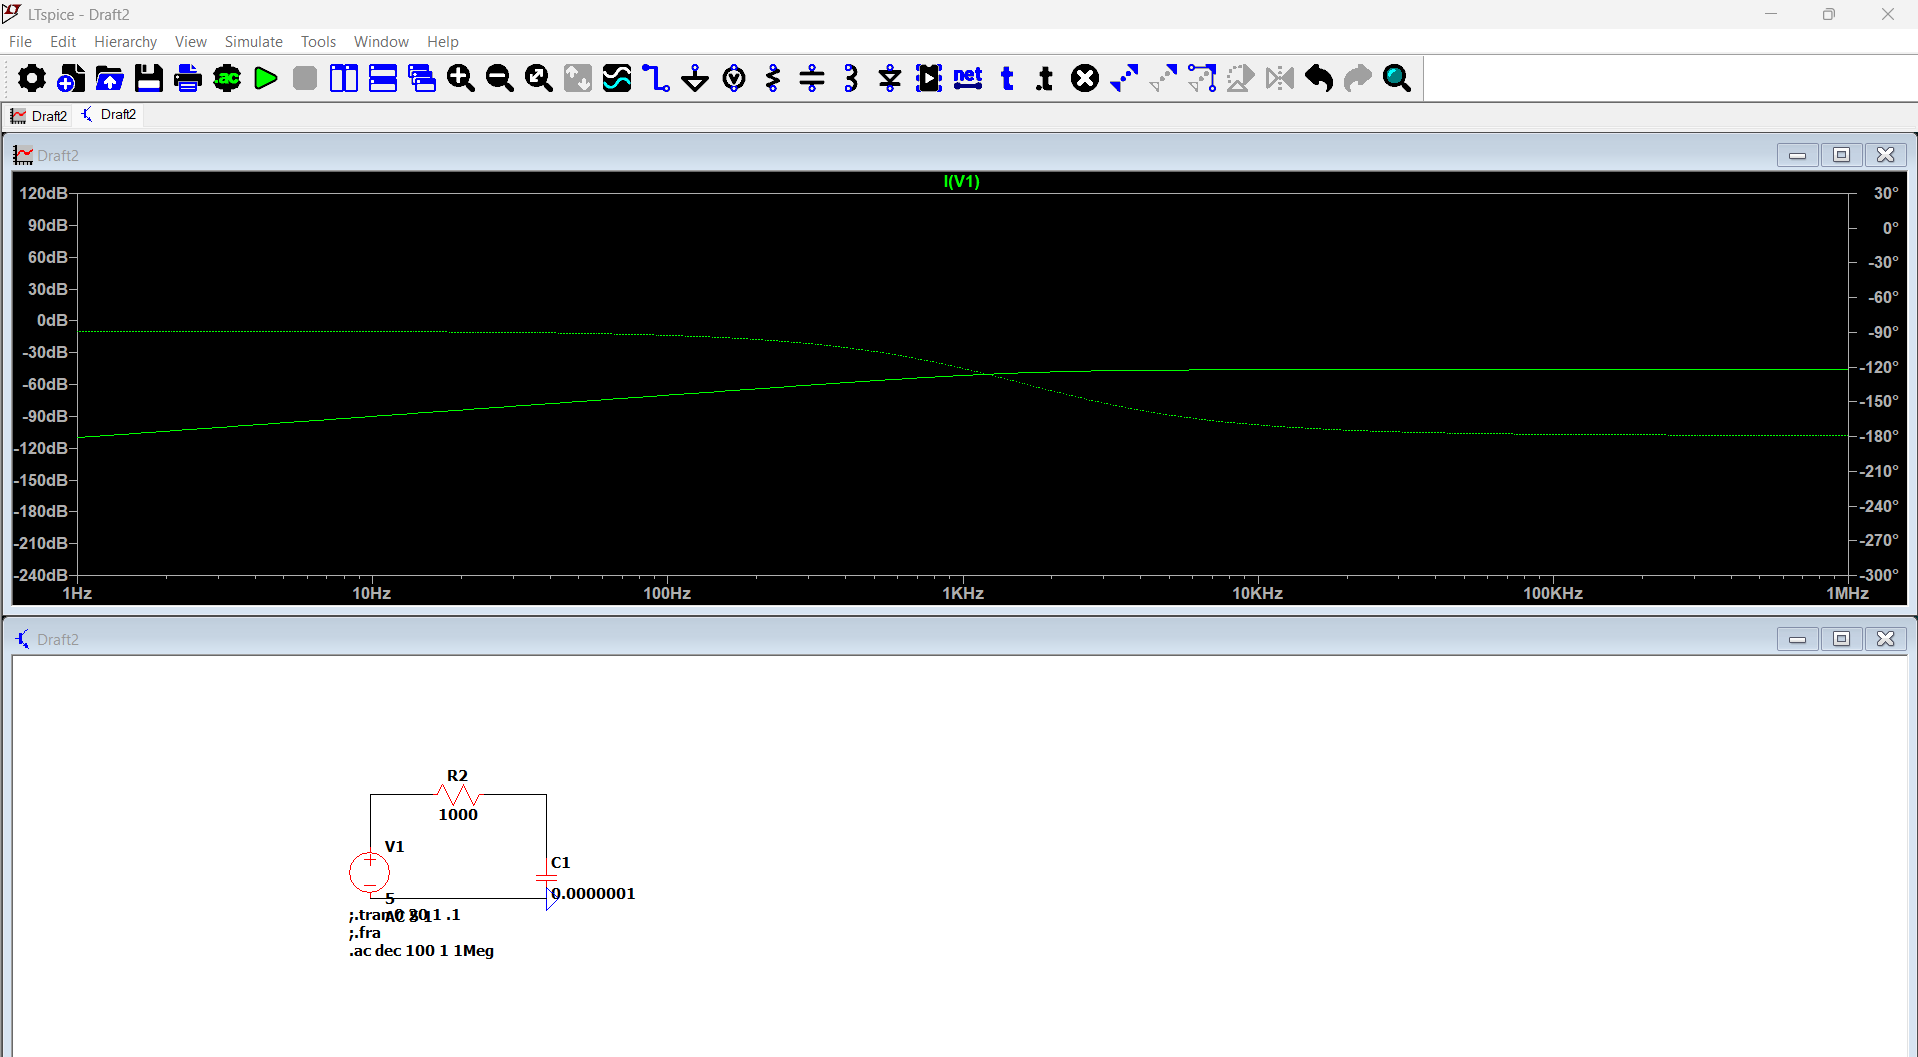

Vpython simulation graph: 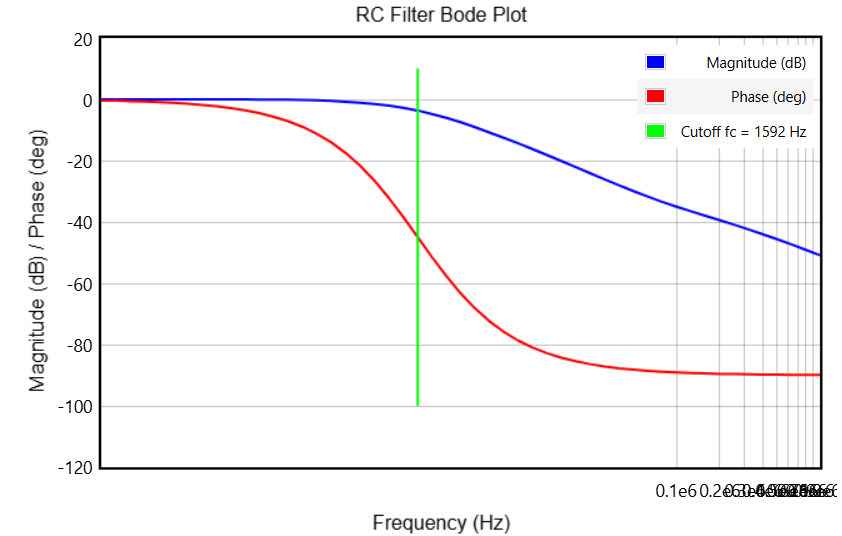

Lt spice magnitude is flipped for some reason and couldn't fix it but it is almost the same as my simulation


b.
Vpyhton Simulation Graph1:
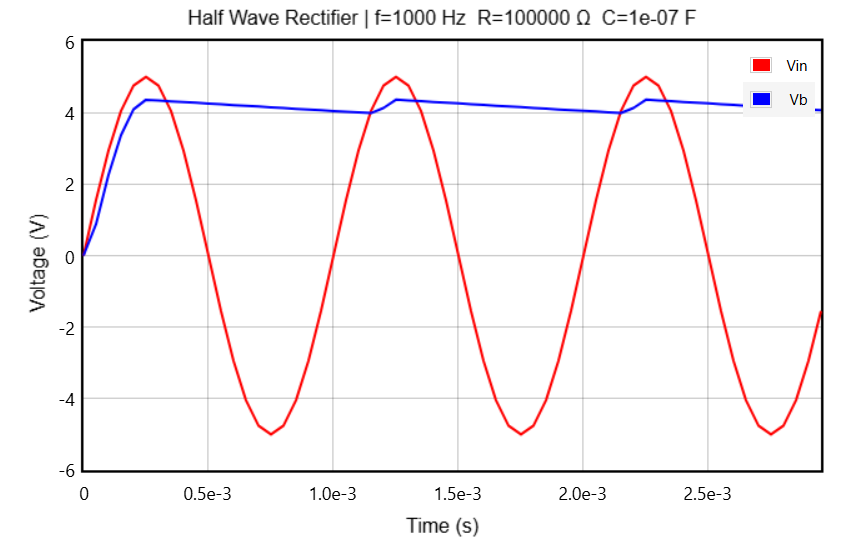

LtSpice Simulation graph:
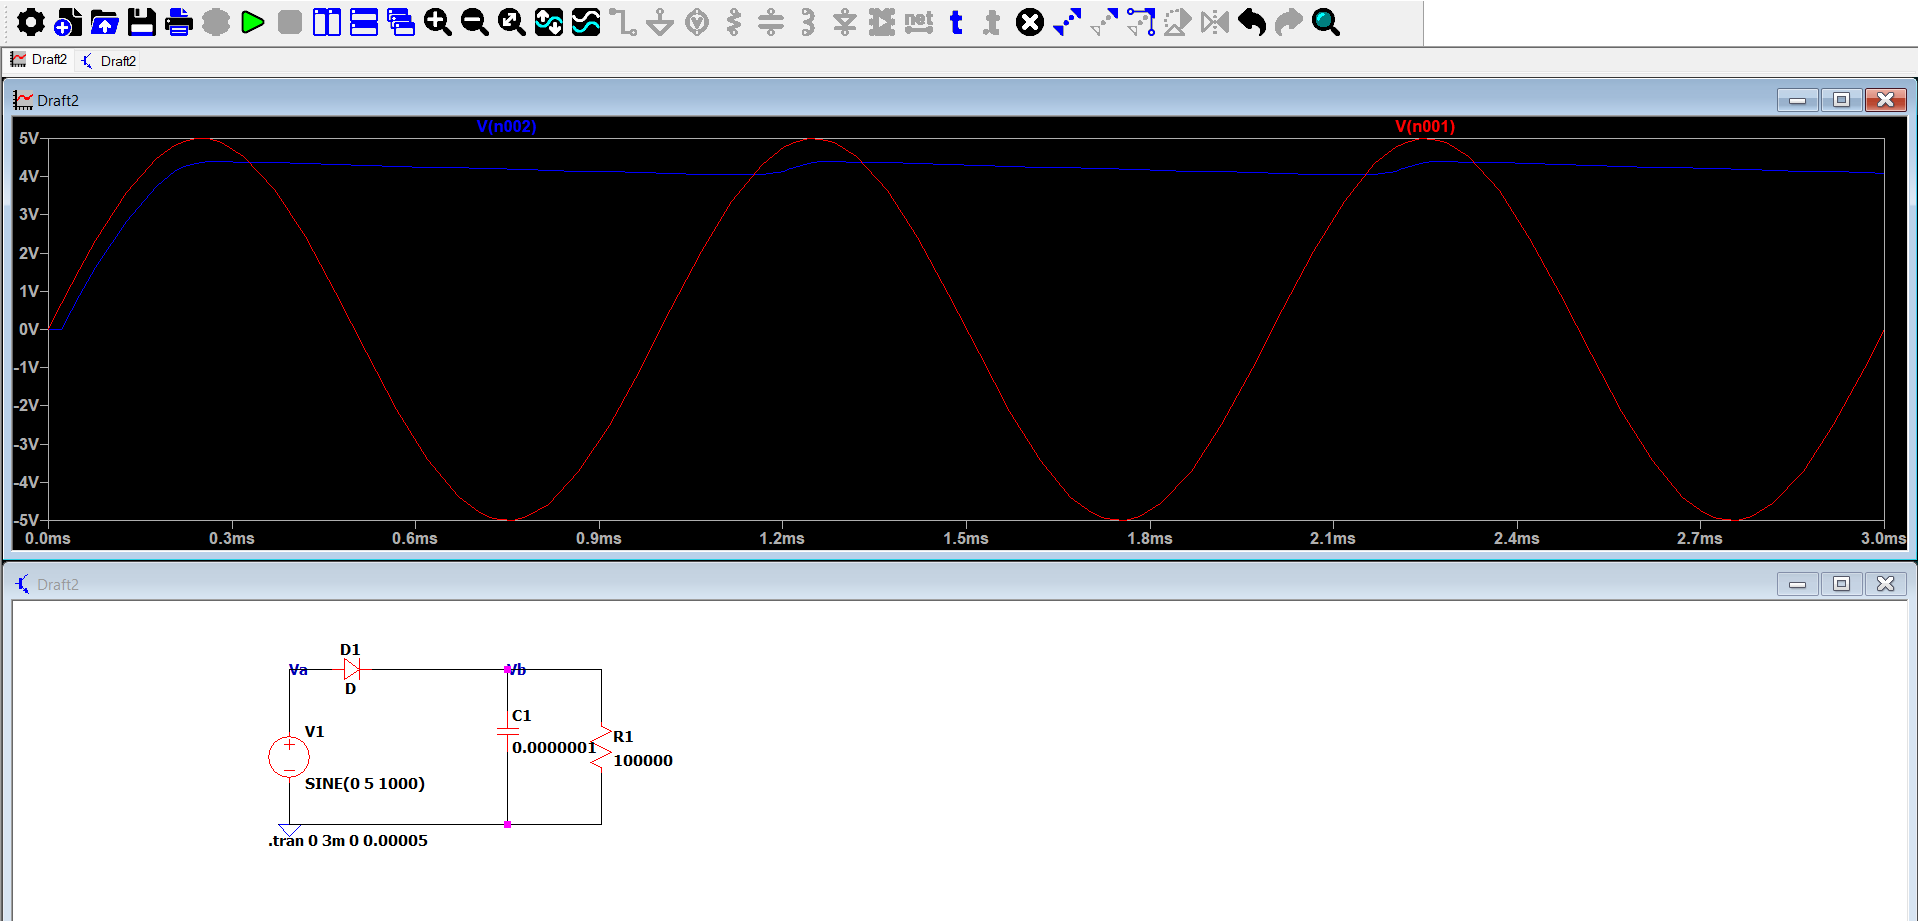

As you can see the Ltspice sim and my current graph are very simular to each other, The red lines for both show Va and the Blue line shows VB indicating my model is correct. Frequency is 1000.

increasing the Capacitance straightens out the VB line after the first rise while decreasing capacitance shows a more destinct oscillating pattern:
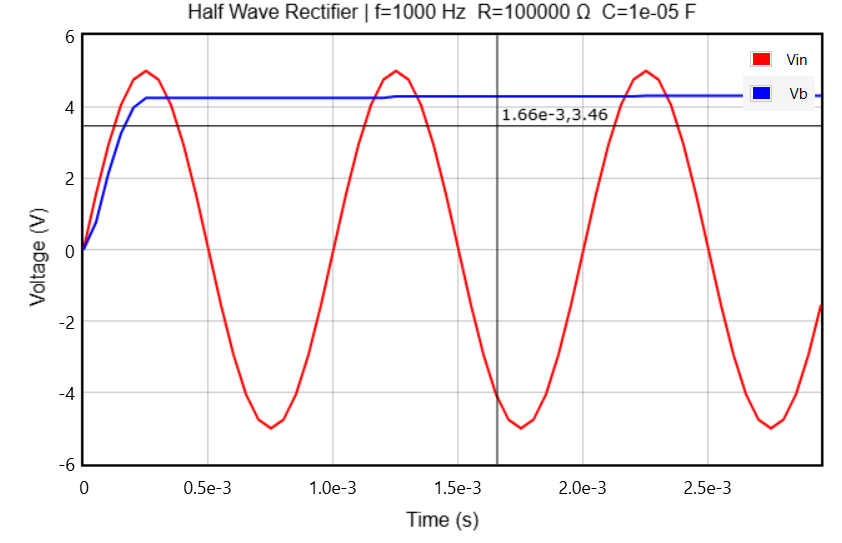
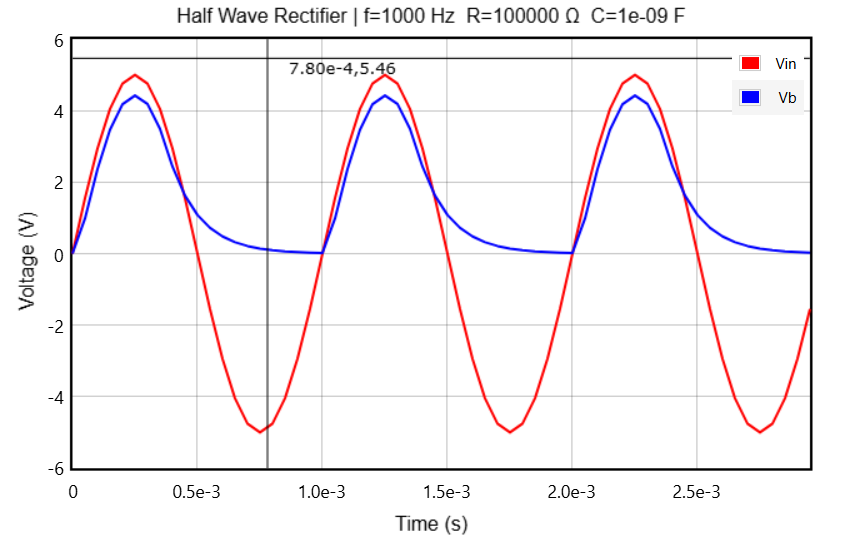
Increasing or decreasing resistance will also have the same effect as the capacitors since both have an affect on the voltage oscillaion:
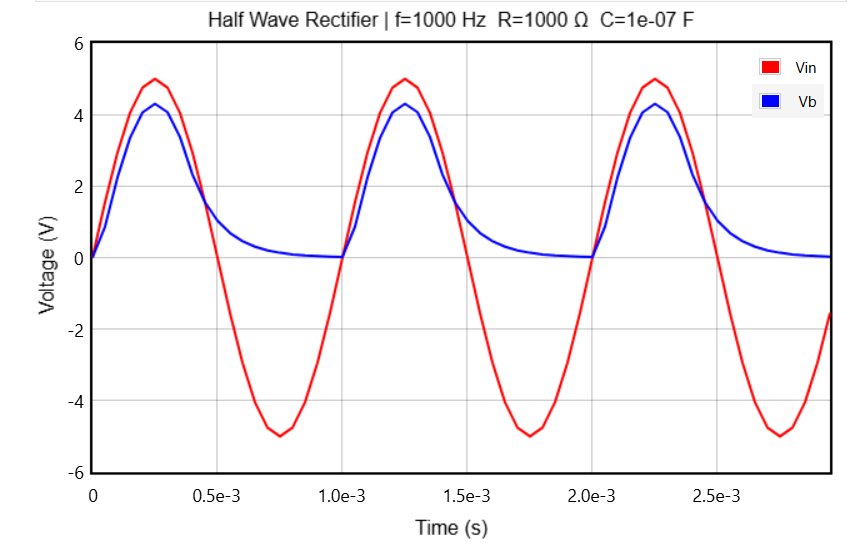
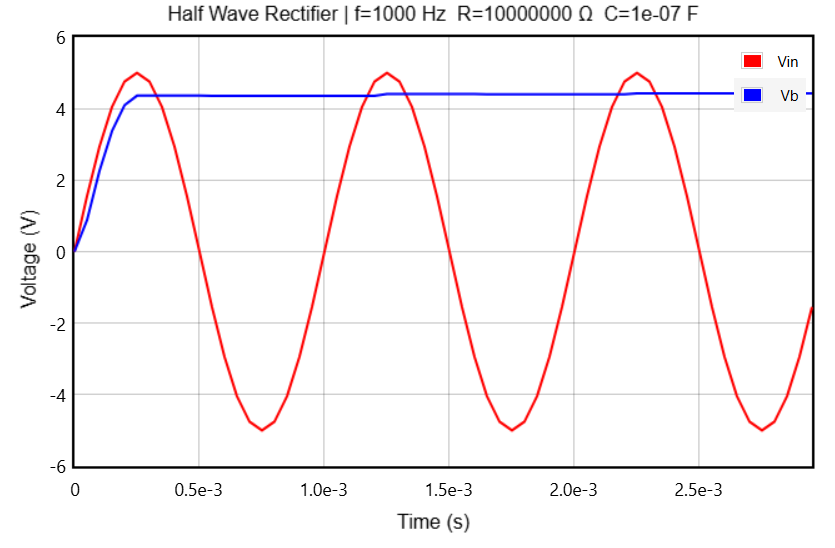


20 sample cycles:
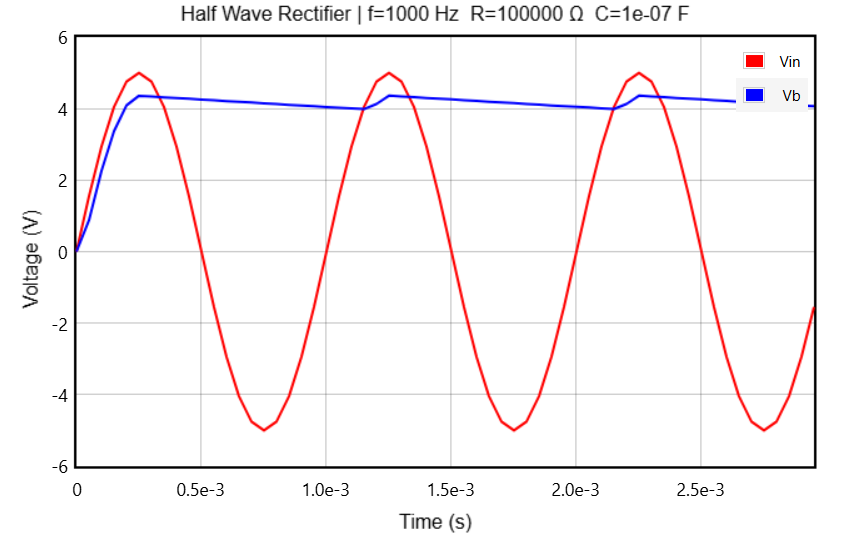

1 Sample cycle:
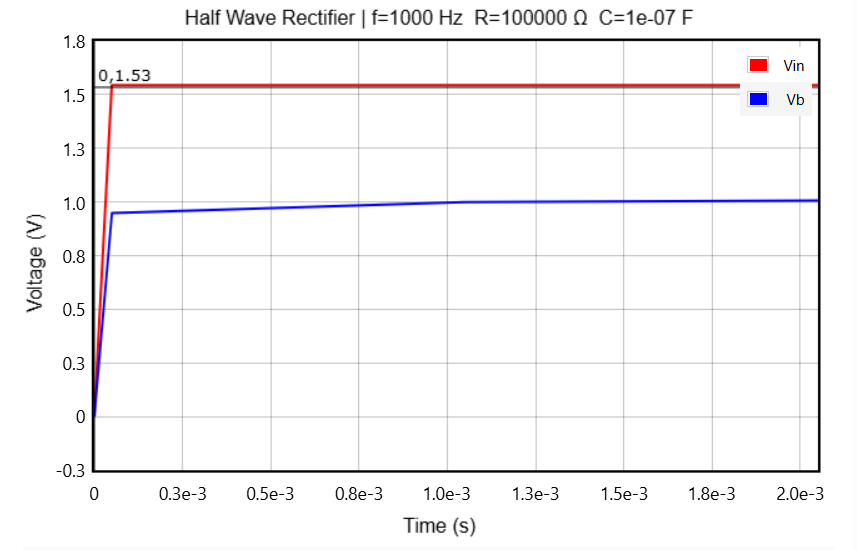

50 sample cycles
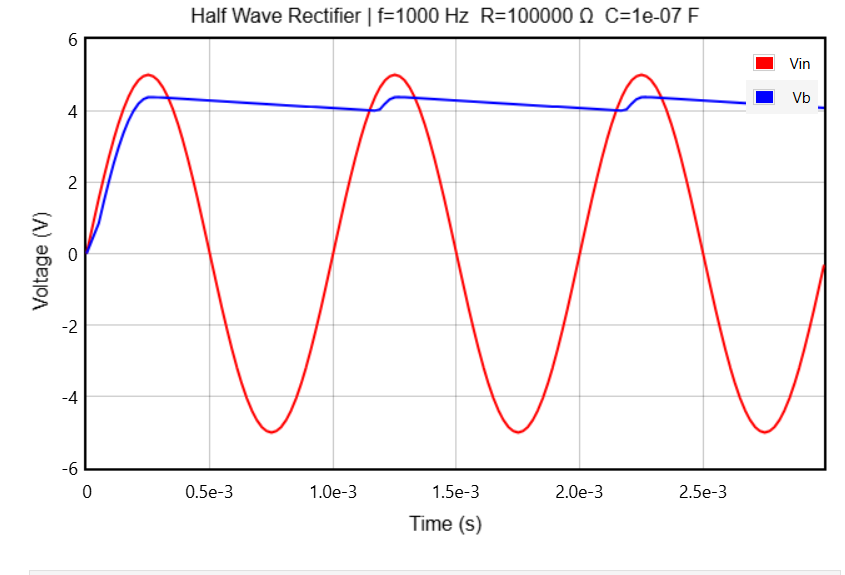

2 sample cycles
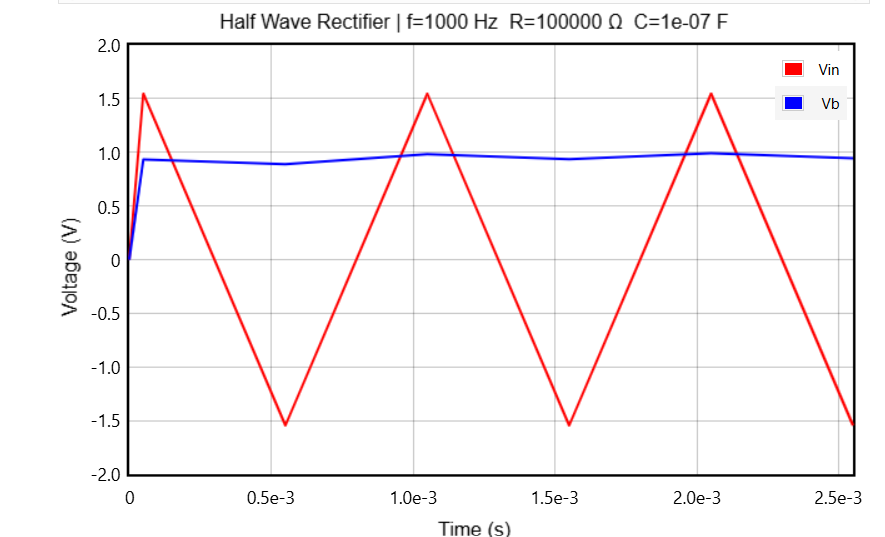

For dt choice, I choose to use the equation: dt = 1 / (sample_cycles * f) which is the Nyquist sampling criterion. From this we can tell that 1 sample makes the sim go to fast and thus never see the voltages oscillate. 2 is the min needed to oscillate but the shape looks to jagged. At 20 you get enough a small enough time step to show the oscilating trend clearly and at 50 the lines in for the voltages are much smoother. All of these made my circuit converge showing that frequeny has the most effect on convergence so in order for it to not converge I made the freq to 100000 instead of 1000 and then made then compare 20 sample cycles to 1 sample cycle and 20 it converges but at 1 it doesn't:
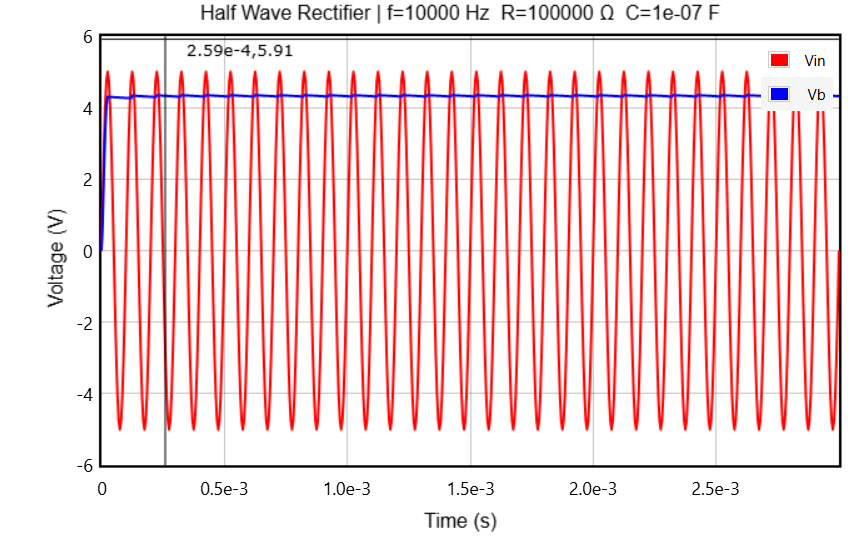
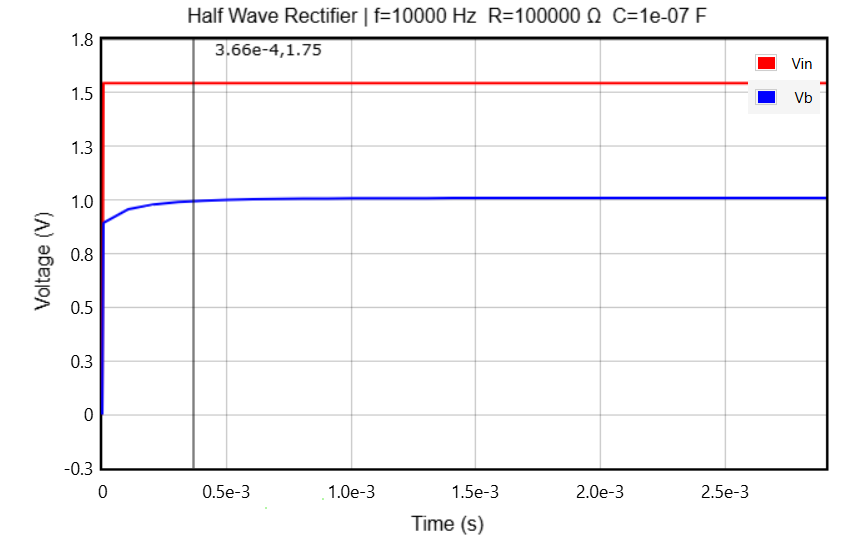